In [1]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class BrainMRIDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_files = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        return image

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


In [3]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [4]:
data_root = "keras_png_slices_data/keras_png_slices_data"

train_dataset = BrainMRIDataset(
    os.path.join(data_root, "keras_png_slices_train"), transform=transform
)
test_dataset = BrainMRIDataset(
    os.path.join(data_root, "keras_png_slices_test"), transform=transform
)
validate_dataset = BrainMRIDataset(
    os.path.join(data_root, "keras_png_slices_validate"), transform=transform
)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}, Validate: {len(validate_dataset)}")

Train: 9664, Test: 544, Validate: 1120


In [5]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
validate_loader = DataLoader(validate_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

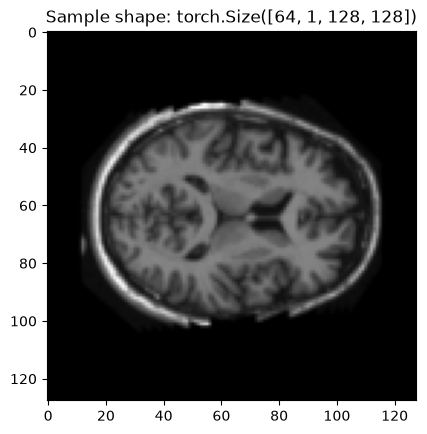

In [6]:
sample_batch = next(iter(train_loader))
plt.imshow(sample_batch[0].squeeze(), cmap='gray')
plt.title(f"Sample shape: {sample_batch.shape}")
plt.show()

In [7]:
import torch.nn.functional as F

LATENT_DIM = 128

class Encoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.conv1 = nn.Conv2d(1,   32, kernel_size=4, stride=2, padding=1)  # 128 -> 64
        self.conv2 = nn.Conv2d(32,  64, kernel_size=4, stride=2, padding=1)  # 64  -> 32
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)  # 32  -> 16
        self.conv4 = nn.Conv2d(128,256, kernel_size=4, stride=2, padding=1)  # 16  -> 8

        self.flatten_dim = 256 * 8 * 8

        self.fc_mu     = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = x.view(x.size(0), -1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

In [8]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.flatten_dim = 256 * 8 * 8

        self.fc = nn.Linear(latent_dim, self.flatten_dim)

        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)  # 8  -> 16
        self.deconv2 = nn.ConvTranspose2d(128,  64, kernel_size=4, stride=2, padding=1)  # 16 -> 32
        self.deconv3 = nn.ConvTranspose2d(64,   32, kernel_size=4, stride=2, padding=1)  # 32 -> 64
        self.deconv4 = nn.ConvTranspose2d(32,    1, kernel_size=4, stride=2, padding=1)  # 64 -> 128

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 256, 8, 8)

        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = F.relu(self.deconv3(x))
        x = torch.sigmoid(self.deconv4(x))
        return x

In [9]:
class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [10]:
model = VAE().to(device)
sample_batch = sample_batch.to(device)
recon, mu, logvar = model(sample_batch)

print("Input shape:", sample_batch.shape)
print("Reconstruction shape:", recon.shape)
print("mu shape:", mu.shape)
print("logvar shape:", logvar.shape)

Input shape: torch.Size([64, 1, 128, 128])
Reconstruction shape: torch.Size([64, 1, 128, 128])
mu shape: torch.Size([64, 128])
logvar shape: torch.Size([64, 128])


In [ ]:
def vae_loss(recon, x, mu, logvar):
    # --- Reconstruction loss ---
    # Binary cross-entropy between reconstruction and input, summed over
    # all pixels and the whole batch (not averaged).
    recon_loss = F.binary_cross_entropy(recon, x, reduction='sum')

    # --- KL divergence loss ---
    # Closed-form KL divergence between N(mu, sigma^2) and N(0, 1),
    # summed over the latent dimension and the batch.
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss_sum = 0.0
    recon_loss_sum = 0.0
    kl_loss_sum = 0.0

    for x in train_loader:
        x = x.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss_sum += loss.item()
        recon_loss_sum += recon_loss.item()
        kl_loss_sum += kl_loss.item()

    avg_total_loss = total_loss_sum / len(train_dataset)
    avg_recon_loss = recon_loss_sum / len(train_dataset)
    avg_kl_loss = kl_loss_sum / len(train_dataset)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Total Loss: {avg_total_loss:.4f} | Recon Loss: {avg_recon_loss:.4f} | KL Loss: {avg_kl_loss:.4f}")

Epoch 1/10 | Total Loss: 4763.1712 | Recon Loss: 4743.9804 | KL Loss: 19.1909
Epoch 2/10 | Total Loss: 4283.1072 | Recon Loss: 4262.2161 | KL Loss: 20.8911
Epoch 3/10 | Total Loss: 4221.5851 | Recon Loss: 4194.7523 | KL Loss: 26.8328
Epoch 4/10 | Total Loss: 4189.4076 | Recon Loss: 4159.6520 | KL Loss: 29.7556
Epoch 5/10 | Total Loss: 4168.2071 | Recon Loss: 4137.3101 | KL Loss: 30.8971
Epoch 6/10 | Total Loss: 4149.5980 | Recon Loss: 4120.0082 | KL Loss: 29.5898
Epoch 7/10 | Total Loss: 4144.9319 | Recon Loss: 4114.5403 | KL Loss: 30.3916
Epoch 8/10 | Total Loss: 4130.9195 | Recon Loss: 4102.4181 | KL Loss: 28.5015
Epoch 9/10 | Total Loss: 4124.0488 | Recon Loss: 4096.2425 | KL Loss: 27.8062
Epoch 10/10 | Total Loss: 4117.5799 | Recon Loss: 4090.3766 | KL Loss: 27.2033


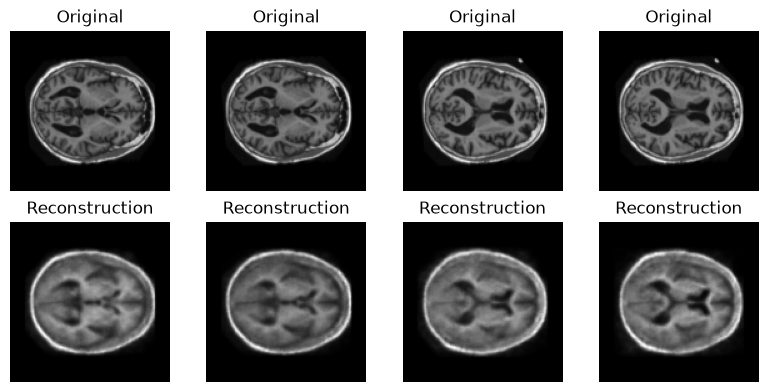

In [13]:
model.eval()
val_batch = next(iter(validate_loader))
val_batch = val_batch.to(device)

with torch.no_grad():
    recon, mu, logvar = model(val_batch)

n = 4
fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))

for i in range(n):
    axes[0, i].imshow(val_batch[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    axes[1, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title("Reconstruction")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [14]:
!pip install umap-learn

  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
Using cached umap_learn-0.5.12-py3-none-any.whl (91 kB)
Using cached pynndescent-0.6.0-py3-none-any.whl (73 kB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl (8.4 MB)

   ---------------------------------------- 0/4 [joblib]
   ---------------------------------------- 0/4 [joblib]
   ---------------------------------------- 0/4 [joblib]
   ---------------------------------------- 0/4 [joblib]
   ---------------------------------------- 0/4 [joblib]
   ---------------------------------------- 0/4 [joblib]
   ---------------------------------------- 0/4 [joblib]
   ---------------------------------------- 0/4 [joblib]
   ---------------------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\aadit\OneDrive\Desktop\oasis-vae-unet-gan\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(1120, 128)


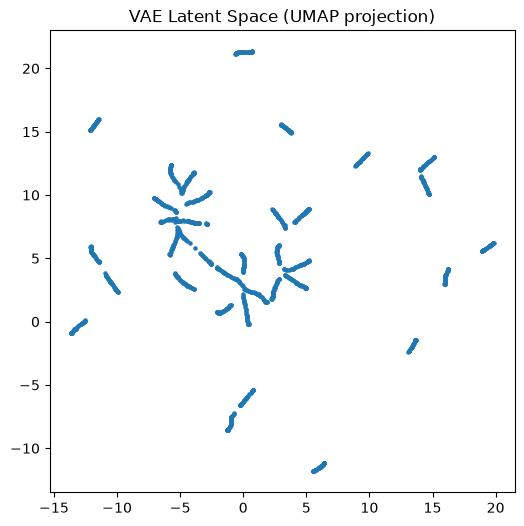

In [ ]:
# --- UMAP projection of the latent space ---
import numpy as np
import umap

model.eval()
mus = []

with torch.no_grad():
    for x in validate_loader:
        x = x.to(device)
        mu, logvar = model.encoder(x)
        mus.append(mu.cpu().numpy())

mus = np.concatenate(mus, axis=0)
print(mus.shape)

reducer = umap.UMAP(n_components=2)
embedding = reducer.fit_transform(mus)

# Each point here is one real validation image's encoded position in
# latent space, projected down from 128D to 2D.
plt.figure(figsize=(6, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], s=5)
plt.title("VAE Latent Space (UMAP projection)")
plt.show()

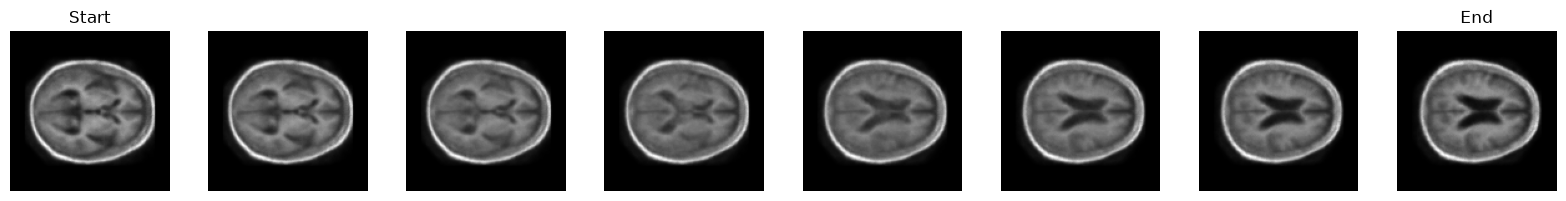

In [17]:
# --- Latent space interpolation walk ---
model.eval()
batch = next(iter(validate_loader))
batch = batch.to(device)

with torch.no_grad():
    mu, logvar = model.encoder(batch)

# Use mu directly (not a sampled z) so the walk is deterministic/reproducible.
z_start = mu[0]
z_end = mu[20]

n_steps = 8
alphas = torch.linspace(0, 1, n_steps).to(device)

fig, axes = plt.subplots(1, n_steps, figsize=(2 * n_steps, 2))

with torch.no_grad():
    for i, alpha in enumerate(alphas):
        z = torch.lerp(z_start, z_end, alpha)
        decoded = model.decoder(z.unsqueeze(0))
        axes[i].imshow(decoded[0].cpu().squeeze(), cmap='gray')
        axes[i].axis('off')

axes[0].set_title("Start")
axes[-1].set_title("End")

plt.tight_layout()
plt.show()